In [1]:
!pip install numpy matplotlib scikit-learn tensorflow keras

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

df = pd.read_excel("/kaggle/input/yahoo-finance-dataset-2018-2023/yahoo_data.xlsx")
df.head()

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.head(20)

,Date,Open,High,Low,Close*,Adj Close**,Volume
1257,2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000
1256,2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000
1255,2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000
1254,2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000
1253,2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000
1252,2018-05-08,24341.35,24412.34,24198.34,24360.21,24360.21,344940000
1251,2018-05-09,24399.18,24586.48,24323.87,24542.54,24542.54,361580000
1250,2018-05-10,24591.66,24794.99,24575.91,24739.53,24739.53,304210000
1249,2018-05-11,24758.64,24868.65,24717.50,24831.17,24831.17,274150000
1248,2018-05-14,24879.37,24994.19,24862.52,24899.41,24899.41,282860000


In [4]:
data = df[['Close*']].values

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
print(data)

[[24099.05]
 [23924.98]
 [23930.15]
 ...
 [33301.87]
 [33826.16]
 [34098.16]]


In [7]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])  
        y.append(data[i + seq_length])   
    return np.array(X), np.array(y)

seq_length = 60 
X, y = create_sequences(scaled_data, seq_length)


In [8]:
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [17]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mean_squared_error'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1 )

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0023 - val_mean_squared_error: 0.0023
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0023 - val_mean_squared_error: 0.0023
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0022 - val_mean_squared_error: 0.0022
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - mean_squared_error: 0.0052 - val_loss: 0.0022 - val_mean_squared_error: 0.0022
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0027 - val_mean_squared_error: 0.0027
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0022 - val_mean_squared_error: 0.0022
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0020 - va

In [20]:
predicted_prices = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


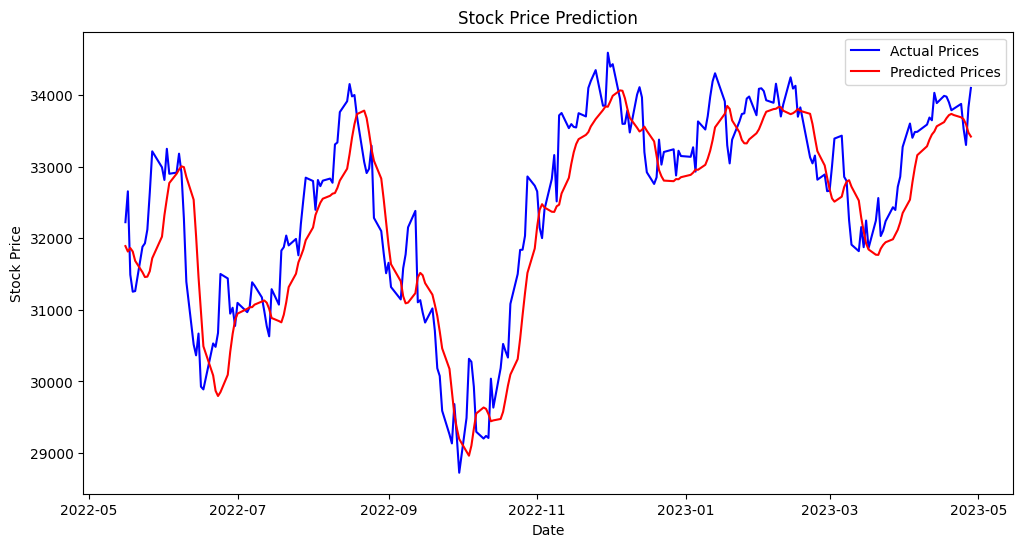

In [23]:
plt.figure(figsize=(12, 6))
actual_prices = df['Close*'].iloc[train_size + seq_length:].values
plt.plot(df['Date'].iloc[train_size + seq_length:], actual_prices, color='blue', label='Actual Prices')
plt.plot(df['Date'].iloc[train_size + seq_length:], predicted_prices, color='red', label='Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()

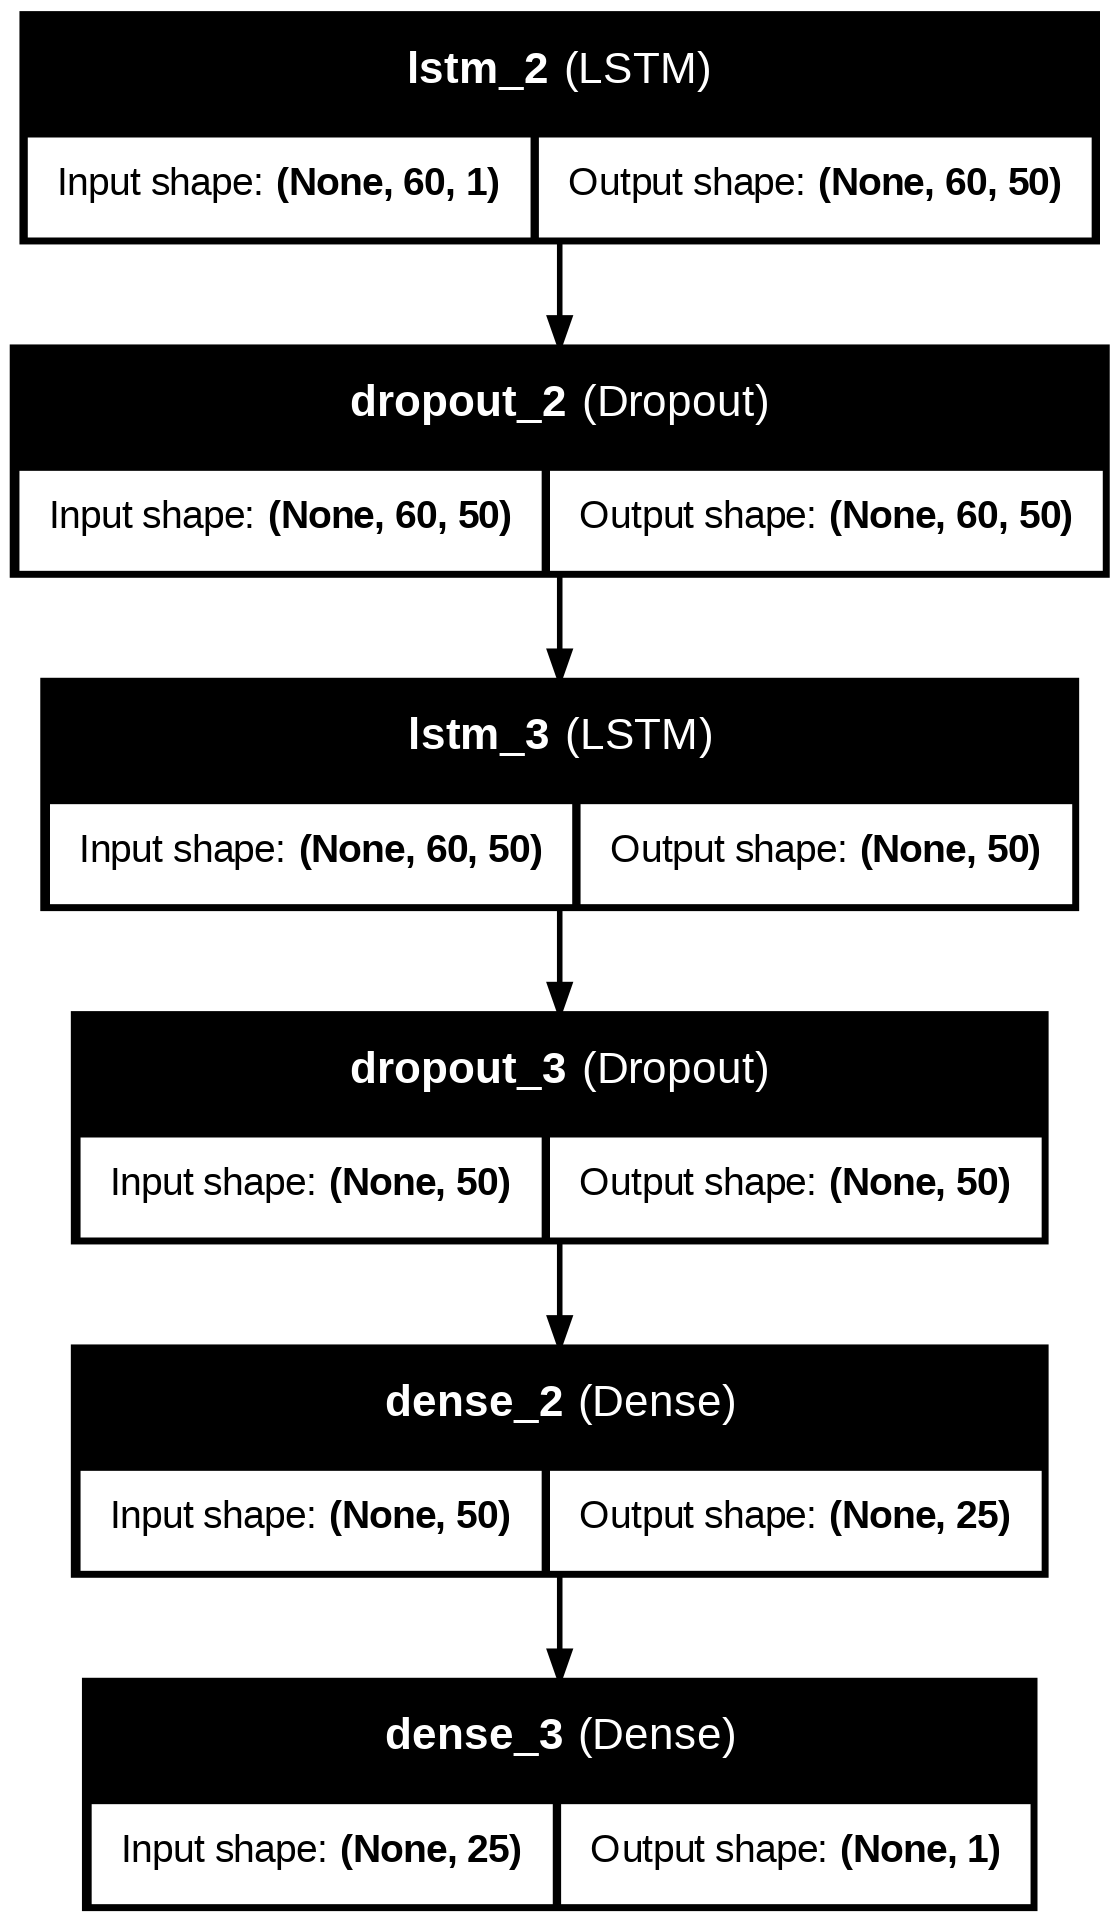

In [24]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

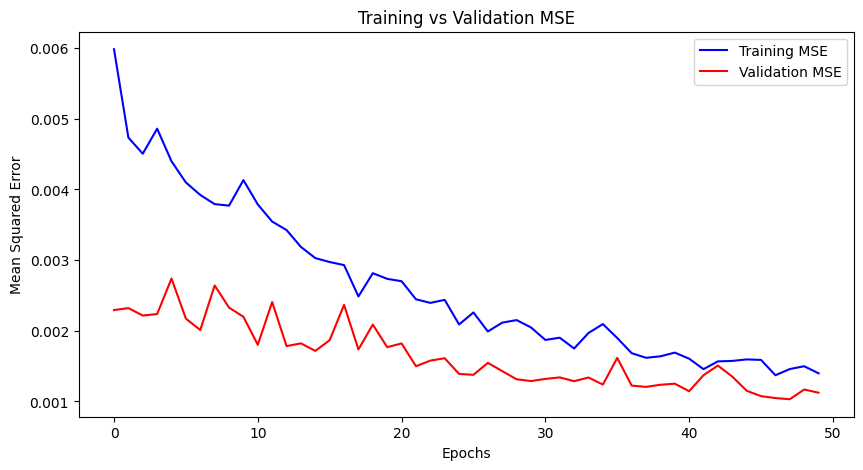

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['mean_squared_error'], label='Training MSE', color='blue')
plt.plot(history.history['val_mean_squared_error'], label='Validation MSE', color='red')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation MSE')
plt.legend()
plt.show()

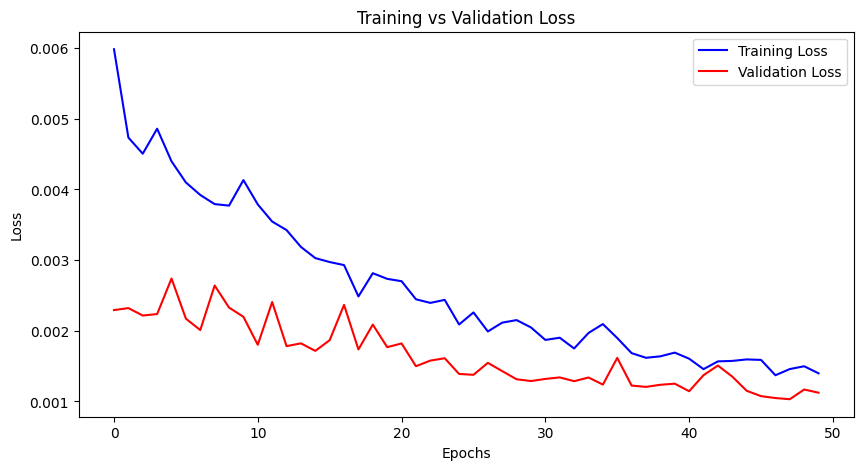

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [27]:
model.save("stock_price_model.h5")